In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import random
import pandas as pd
import seaborn as sns
%matplotlib inline

GPU_ID = 1  # Select which GPU to use
DEVICE = torch.device('cuda:'+str(GPU_ID) if torch.cuda.is_available() else 'cpu') 
print(DEVICE)
print("torch: ", torch.__version__)

print("numpy: ", np.__version__)
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

cuda:1
torch:  2.7.1+cu128
numpy:  1.26.4


In [2]:
data_root = 'd:/bcss/images/'
mask_root = 'd:/bcss/mask/'
out_root =  'd:/bcss/tensors/'
training_root =  'd:/bcss/training/'
test_root = 'd:/bcss/test/'

file_names = os.listdir(out_root)


In [3]:
max_class = 5
total_preds = {} 
total_features = {}
total_labels = {}

for i in range(max_class):
    total_preds[i] = []
    total_features[i] = []
    total_labels[i] = []

cnt = 0

tensor_data_file_name = training_root + "bcss.local.training.torch"

selected = 100000 # use this many samples from each files
print(file_names)

for f in file_names:
    cnt += 1
    print("cnt: ", cnt)
    if cnt > 4:  # Use data for trianing from files below this threshold. The rest of the files can be used for training.
        break
        
    # torch.save({'predictions':preds_merged, 'features':features_merged, 'mask':mask}, out_tensor_file)
    data = torch.load(out_root+f, weights_only=False)
    # print(data)
    predictions = data['predictions']
    features = data['features']
    labels = torch.tensor(data['mask'])

    (col, row) = labels.shape
    print("col, row: ", col,row)
    predictions = torch.flatten(predictions, start_dim=2)    
    features = torch.flatten(features, start_dim=2)    
    labels = torch.flatten(labels, start_dim=0)
    # print(predictions.shape)
    # print(features.shape)
    # print(labels.shape)
    # print(labels.dtype)
    for i in range(max_class):
        idx = torch.where(labels == i)[0].tolist()
        idx = random.sample(idx, np.min((len(idx), selected)))
        # print(len(idx))
        # print(random.sample(idx, np.min((len(idx), selected))))
        # break
        # print(predictions[0,:,idx].shape)
        # print(features[0,:,idx].shape)
        total_preds[i].append(predictions[0,:,idx])
        total_features[i].append(features[0,:,idx])
    # break
        
        
    
for i in range(max_class):
    print("class ID: ", i)
    total_preds[i] = torch.cat(total_preds[i], dim=1)
    indexes = torch.randperm(total_preds[i].shape[1])
    total_preds[i] = total_preds[i][:,indexes]
    
    total_features[i] = torch.cat(total_features[i], dim=1)
    # indexes = torch.randperm(total_features[i].shape[1])
    total_features[i] = total_features[i][:,indexes]

    print("Predictins: ", total_preds[i].shape)
    print("Features: ", total_features[i].shape)
# print(total_preds)
# print(total_features)

torch.save({'total_preds':total_preds, 'total_features':total_features}, tensor_data_file_name)


['TCGA-E2-A1LK-DX1_xmin75611_ymin27593_MPP-0.2500.png.tensor', 'TCGA-E2-A1LS-DX1_xmin39247_ymin47756_MPP-0.2500.png.tensor', 'TCGA-EW-A1PH-DX1_xmin3455_ymin52049_MPP-0.2500.png.tensor', 'TCGA-GM-A2DF-DX1_xmin50637_ymin43774_MPP-0.2500.png.tensor']
cnt:  1
col, row:  3268 2502
cnt:  2
col, row:  1171 1314
cnt:  3
col, row:  2623 2924
cnt:  4
col, row:  1981 2026
class ID:  0
Predictins:  torch.Size([5, 400000])
Features:  torch.Size([64, 400000])
class ID:  1
Predictins:  torch.Size([5, 400000])
Features:  torch.Size([64, 400000])
class ID:  2
Predictins:  torch.Size([5, 368307])
Features:  torch.Size([64, 368307])
class ID:  3
Predictins:  torch.Size([5, 154293])
Features:  torch.Size([64, 154293])
class ID:  4
Predictins:  torch.Size([5, 0])
Features:  torch.Size([64, 0])


In [634]:


# this is good: test_file_name = "TCGA-E2-A1LS-DX1_xmin39247_ymin47756_MPP-0.2500.png.tensor"
test_file_name = "TCGA-E2-A1LS-DX1_xmin39247_ymin47756_MPP-0.2500.png.tensor"


# Load the test data
# torch.save({'predictions':preds_merged, 'features':features_merged, 'mask':mask}, out_tensor_file)
test_data = torch.load(out_root+test_file_name, weights_only=False)

predictions = test_data['predictions']
# features = test_data['features']
print(predictions.shape)
labels = torch.tensor(test_data['mask'])
print(labels.shape)
# print(labels[909:930, 909:930])
softmax = torch.nn.Softmax()


predictions = torch.flatten(predictions, start_dim=2).squeeze(0).transpose(0,1)
# features = torch.flatten(features, start_dim=2)    
labels = torch.flatten(labels, start_dim=0)
print(predictions.shape)
print(labels.shape)
labels[labels>4] = 4
print(labels)
# predictions = softmax(predictions, dim=1)
# predictions = predictions - torch.mean(predictions, dim=1).repeat(5,1).transpose(0,1)
# mini_test_sample_num = 1000000

df_tdc = control_fdr_multiclass(predictions, labels, predictions)
qvals = df_tdc['q_values_ground_truth']
plt

torch.Size([1, 5, 1171, 1314])
torch.Size([1171, 1314])
torch.Size([1538694, 5])
torch.Size([1538694])
tensor([1, 1, 1,  ..., 1, 1, 1], dtype=torch.uint8)


<module 'matplotlib.pyplot' from 'C:\\Users\\kfattila\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [98]:
softmax = torch.nn.Softmax()
softmax(predictions).shape

C:\Users\kfattila\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1751: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


torch.Size([1, 5, 1538694])

[0.         0.         0.         ... 0.14909862 0.14909862 0.14909917]


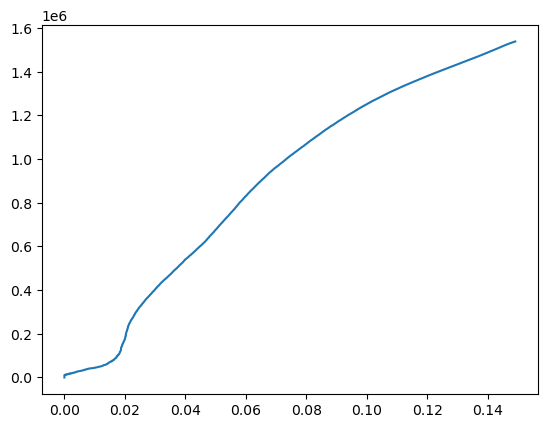

In [635]:
qvals = np.sort(df_tdc['q_values_ground_truth'])
print(qvals)
plt.plot(qvals, np.arange(len(qvals)))
plt.show()


[0.         0.         0.         ... 0.14909807 0.14909862 0.14909917]


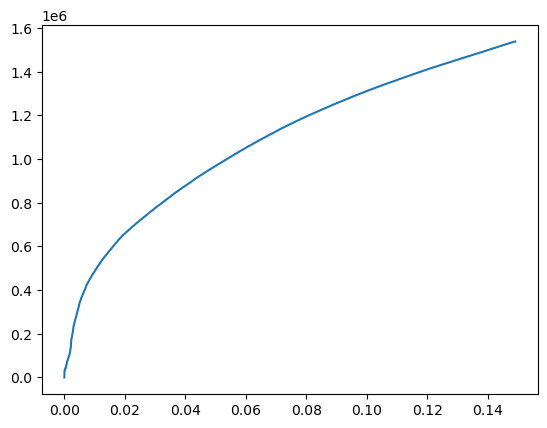

In [102]:
qvals = np.sort(df_tdc['q_values_ground_truth'])
print(qvals)
plt.plot(qvals, np.arange(len(qvals)))
plt.show()

[0.         0.         0.         ... 0.14909862 0.14909862 0.14909917]


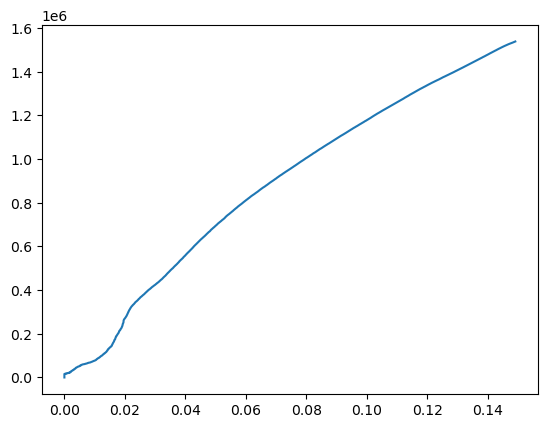

In [132]:
qvals = np.sort(df_tdc['q_values_ground_truth'])
print(qvals)
plt.plot(qvals, np.arange(len(qvals)))
plt.show()

torch.Size([5, 100000])
torch.Size([64, 100000])
torch.Size([1, 5, 1171, 1314])
Target class:  0
training positive max: tensor(35.6808)
training negative max: tensor(28.4838)
test negative max: tensor(6.5939)


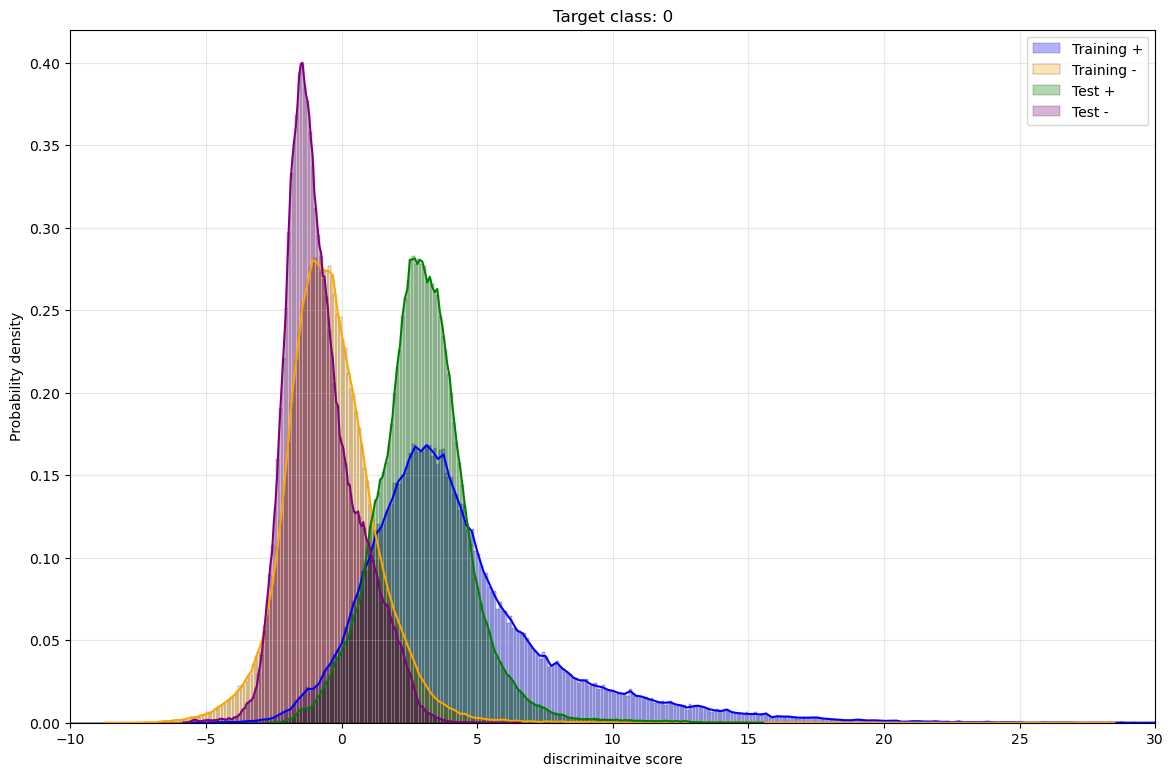

Target class:  1
training positive max: tensor(30.8568)
training negative max: tensor(25.7680)
test negative max: tensor(8.2944)


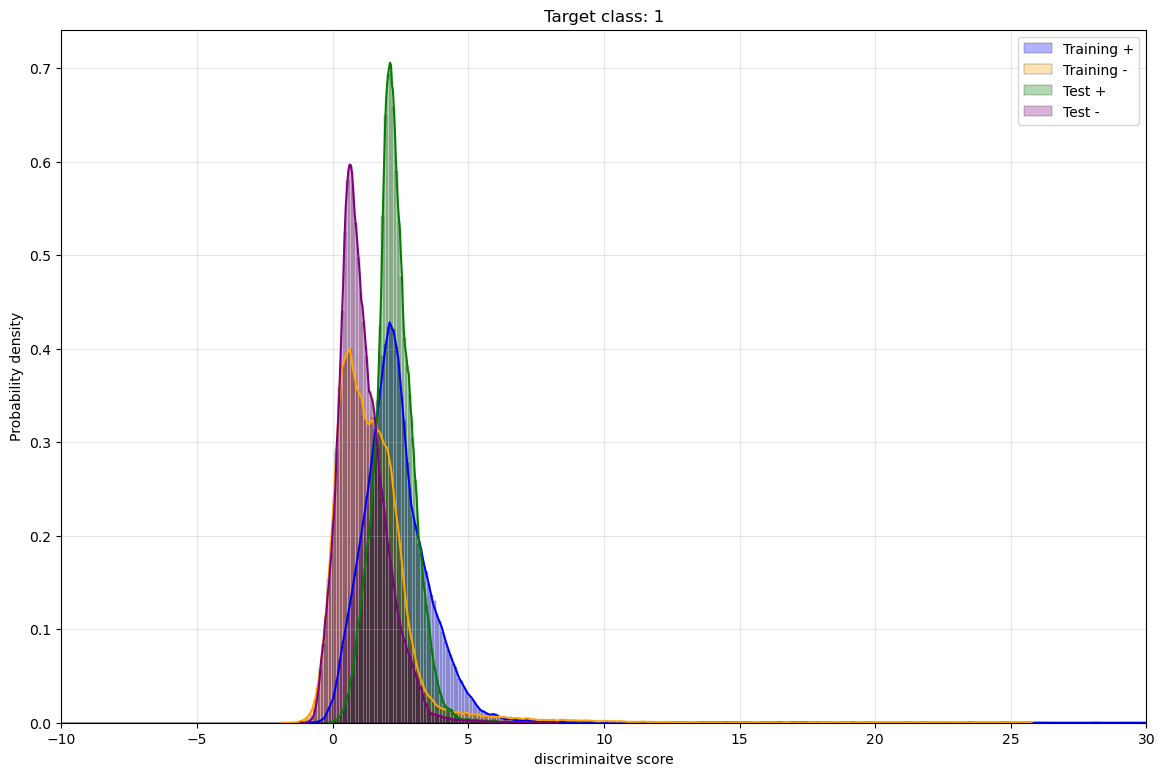

Target class:  2
training positive max: tensor(9.4236)
training negative max: tensor(13.1811)
test negative max: tensor(7.4070)


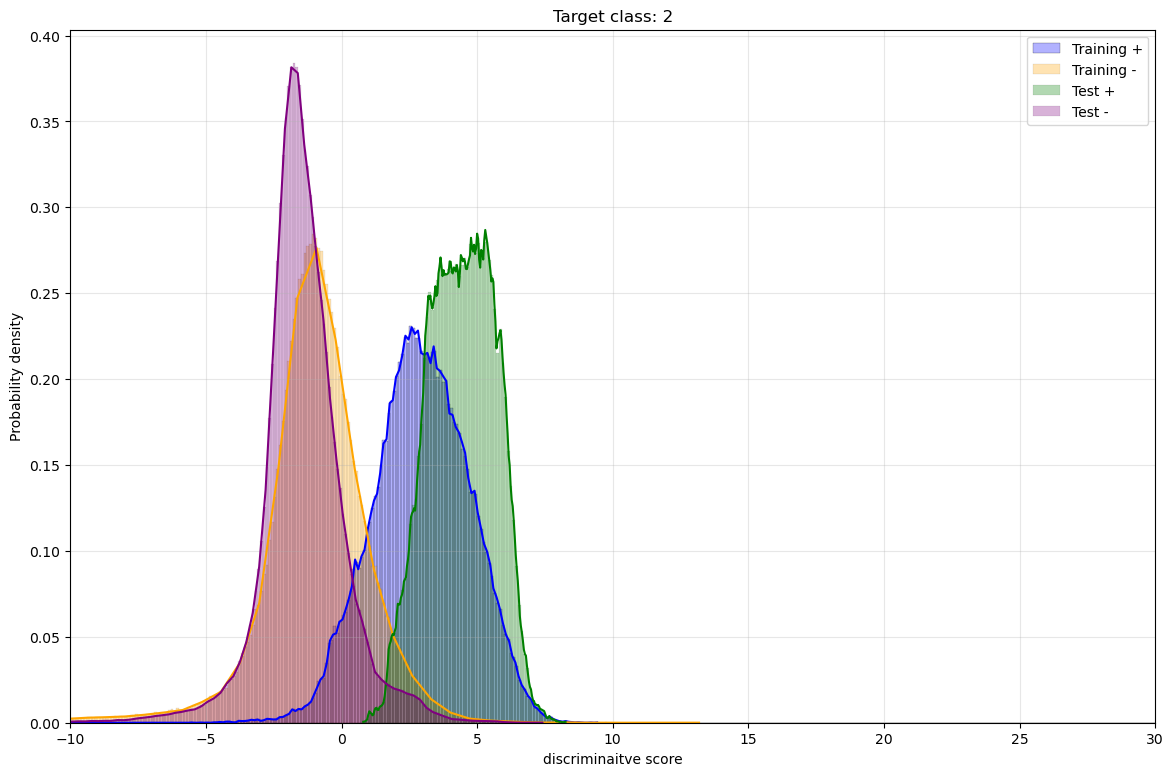

Target class:  3
training positive max: tensor(12.1220)
training negative max: tensor(9.7540)
test negative max: tensor(2.0118)


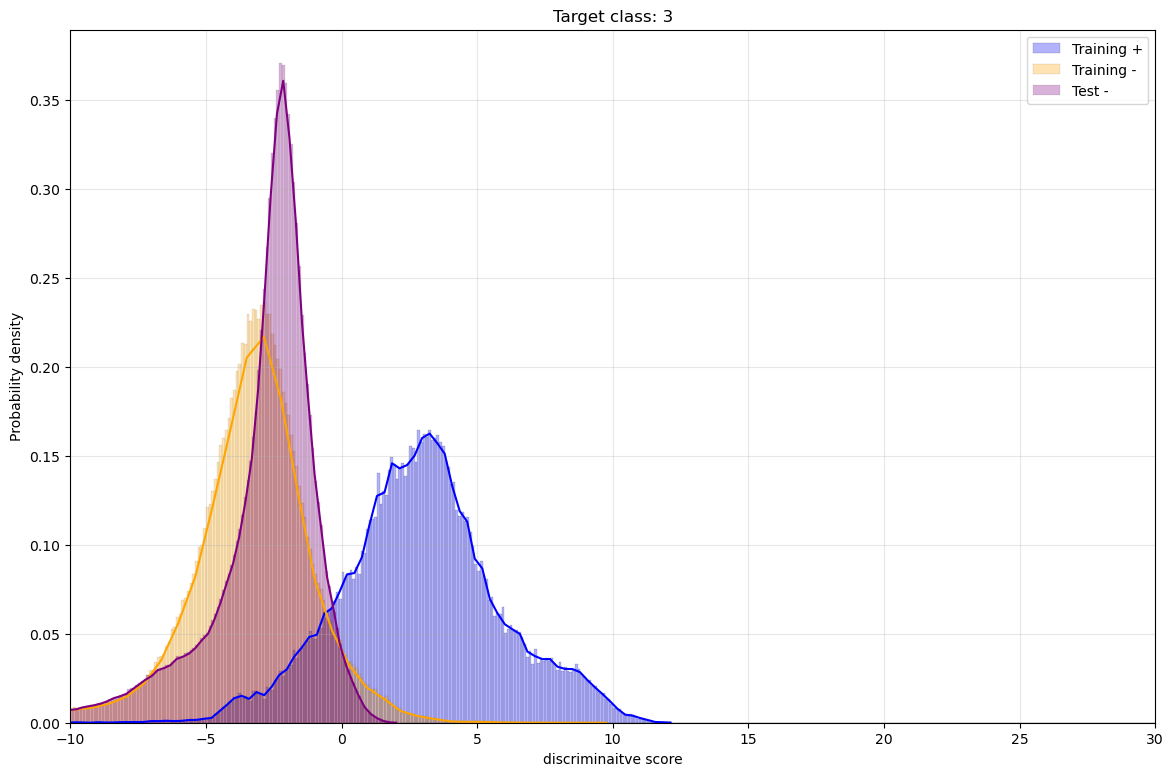

Target class:  4
training positive max: tensor(13.5989)
training negative max: tensor(26.5291)
test negative max: tensor(6.6331)


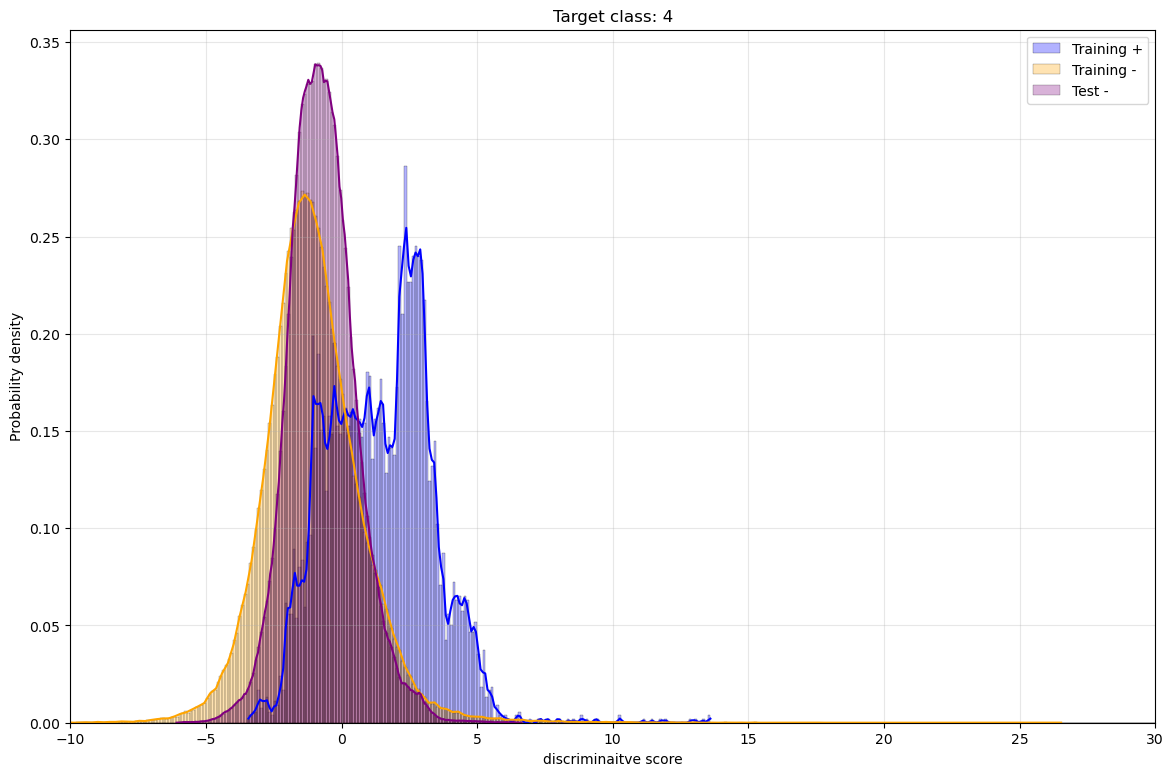

In [142]:

#Plot the training data score distributions

# torch.save({'total_preds':total_preds, 'total_features':total_features}, tensor_data_file_name)
tensor_data_file_name = out_root + "bcss.mini.training.torch"
# Load the training data
training_data = torch.load(tensor_data_file_name, weights_only=False)
training_preds = training_data['total_preds']
print(training_preds[0].shape)

training_features = training_data['total_features']
print(training_features[0].shape)


test_file_name = "TCGA-E2-A1LS-DX1_xmin39247_ymin47756_MPP-0.2500.png.tensor"

# Load the test data
# torch.save({'predictions':preds_merged, 'features':features_merged, 'mask':mask}, out_tensor_file)
test_data = torch.load(out_root+test_file_name, weights_only=False)

predictions = test_data['predictions']
# features = test_data['features']
print(predictions.shape)
labels = torch.tensor(test_data['mask'])

predictions = torch.flatten(predictions, start_dim=2)    
# features = torch.flatten(features, start_dim=2)    
labels = torch.flatten(labels, start_dim=0)

mini_test_sample_num = 10000000
kde_bw = 0.2
max_class = 5
for target_class in range(max_class):
    print("Target class: ", target_class)
    plt.figure(figsize=(14, 9))

    # Plot the training data first
    bins=np.arange(-11,31,0.1)
    positive_data = training_preds[target_class][target_class,:] 
    a=sns.histplot(positive_data, bins=bins, stat="density", color='blue', kde_kws={'bw_adjust': kde_bw}, kde=True, fill=True,  alpha=0.3, label="Training +")    
    print("training positive max:", positive_data.max())
    negative_data = []
    for other_classes in range(max_class):
        if target_class != other_classes:
            negative_data.append(training_preds[other_classes][target_class,:])
    negative_data = torch.cat(negative_data)
    a=sns.histplot(negative_data, bins=bins, stat="density", color='orange', kde_kws={'bw_adjust': kde_bw}, kde=True, fill=True,  alpha=0.3, label="Training -")    
    print("training negative max:", negative_data.max())

    # Plot the test data 
    idx = torch.where(labels == target_class)[0].tolist()
    idx = random.sample(idx, np.min((len(idx), mini_test_sample_num)))
    
    a=sns.histplot(predictions[0,target_class,idx], bins=bins, stat="density", color='green', kde_kws={'bw_adjust': kde_bw}, kde=True, fill=True,  alpha=0.3, label="Test +")    
    idx = torch.where(labels != target_class)[0].tolist()
    idx = random.sample(idx, np.min((len(idx), mini_test_sample_num)))
    a=sns.histplot(predictions[0,target_class,idx], bins=bins, stat="density", color='purple', kde_kws={'bw_adjust': kde_bw} , kde=True, fill=True,  alpha=0.3, label="Test - ")    
    print("test negative max:", predictions[0,target_class,idx].max())
    
    plt.xlabel('discriminaitve score')
    plt.ylabel('Probability density')
    plt.title("Target class: " + str(target_class))
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.xlim(-10,30)
    filename = "Standard_gaussian"
    # plt.savefig(PATH+filename+".png", bbox_inches='tight')
    # plt.savefig(PATH+filename+".pdf", bbox_inches='tight')
    
    plt.show()
    # break

torch.Size([5, 100000])
Target class:  2
torch.Size([4000])


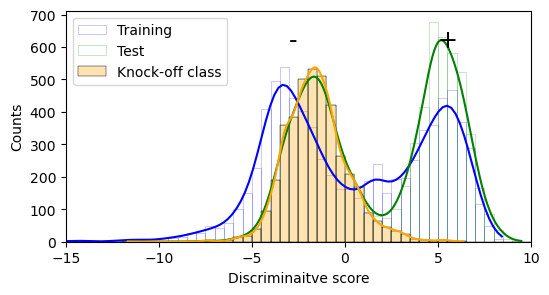

In [383]:

#Plot the training data score distributions

# torch.save({'total_preds':total_preds, 'total_features':total_features}, tensor_data_file_name)
tensor_data_file_name = out_root + "bcss.mini.training.torch"
# Load the training data
training_data = torch.load(tensor_data_file_name, weights_only=False)
training_preds = training_data['total_preds']
print(training_preds[0].shape)



test_file_name = "TCGA-S3-AA10-DX1_xmin43039_ymin23986_MPP-0.2500.png.tensor"

# Load the test data
# torch.save({'predictions':preds_merged, 'features':features_merged, 'mask':mask}, out_tensor_file)
test_data = torch.load(out_root+test_file_name, weights_only=False)

predictions = test_data['predictions']
# features = test_data['features']
labels = torch.tensor(test_data['mask'])

predictions = torch.flatten(predictions, start_dim=2)    
# features = torch.flatten(features, start_dim=2)    
labels = torch.flatten(labels, start_dim=0)

mini_test_sample_num = 4000
kde_bw = 0.8

target_class=2
print("Target class: ", target_class)
plt.figure(figsize=(6, 3))

# Plot the training data first
bins=np.arange(-15,11,0.5)
positive_data = total_preds[target_class][target_class,:] 
# a=sns.histplot(positive_data, bins=bins, stat="density", color='blue', kde_kws={'bw_adjust': kde_bw}, kde=True, fill=True,  alpha=0.3, label="Training +")    
negative_data = []
for other_classes in range(max_class):
    if target_class != other_classes:
        negative_data.append(total_preds[other_classes][target_class,:])
negative_data = torch.cat(negative_data)[0:positive_data.shape[0]]-2
print(negative_data.shape)
a=sns.histplot(torch.cat((positive_data+2,negative_data)), bins=bins, stat="count", color='blue', kde_kws={'bw_adjust': kde_bw}, kde=True, fill=False,  alpha=0.3, label="Training")    

# ax = sns.kdeplot(torch.cat((positive_data,negative_data)), bw_adjust=kde_bw, label='Training', color='blue')
# # Scale to counts
# x, y = ax.lines[0].get_data()
# n = len(torch.cat((positive_data,negative_data)))
# bin_width = x[2] - x[1]
# ax.lines[0].set_ydata(y * n * bin_width/2)


# Plot the test data 
idx = torch.where(labels == target_class)[0].tolist()
idx = random.sample(idx, np.min((len(idx), mini_test_sample_num)))

pos_test_data = predictions[0,target_class,idx] 
# a=sns.histplot(predictions[0,target_class,idx], bins=bins, stat="density", color='green', kde_kws={'bw_adjust': kde_bw}, kde=True, fill=True,  alpha=0.3, label="Test +")    
idx = torch.where(labels != target_class)[0].tolist()
idx = random.sample(idx, np.min((len(idx), mini_test_sample_num)))
a=sns.histplot(torch.cat((pos_test_data+2, predictions[0,target_class,idx]-1)), bins=bins, stat="count", color='green', kde_kws={'bw_adjust': kde_bw} , kde=True, fill=False,  alpha=0.3, label="Test")    
# ax = sns.kdeplot(torch.cat((pos_test_data, predictions[0,target_class,idx]-1)), bw_adjust=kde_bw, label='Test', color='green')
# # Scale to counts
# x, y = ax.lines[1].get_data()
# n = len(torch.cat((pos_test_data, predictions[0,target_class,idx]-1)))
# bin_width = x[2] - x[1]
# ax.lines[1].set_ydata(y * n * bin_width)


a=sns.histplot(predictions[0,target_class,idx]-1, bins=bins, stat="count", color='orange', kde_kws={'bw_adjust': kde_bw} , kde=True, fill=True,  alpha=0.3, label="Knock-off class")    

plt.text(-3, 600, "-", size='xx-large', style='normal')
plt.text(5, 600, "+", size='xx-large', style='normal')

plt.xlabel('Discriminaitve score')
plt.ylabel('Counts')
# plt.title("Target class: " + str(target_class))
plt.legend(loc='upper left')
# plt.grid(True, alpha=0.3)
plt.xlim(-15,10)
# plt.ylim(0,160)
filename = "decoy_null_sketch"
PATH='./'
plt.savefig(PATH+filename+".png", bbox_inches='tight')
plt.savefig(PATH+filename+".pdf", bbox_inches='tight')

plt.show()
# break

In [381]:
pwd()

'D:\\2024-arina-decoy-based-FDR\\bcss'

torch.Size([5, 100000])
training negative max: tensor(7.2166)
training negative max: tensor(9.7540)
training negative max: tensor(3.5889)
training negative max: tensor(6.5364)


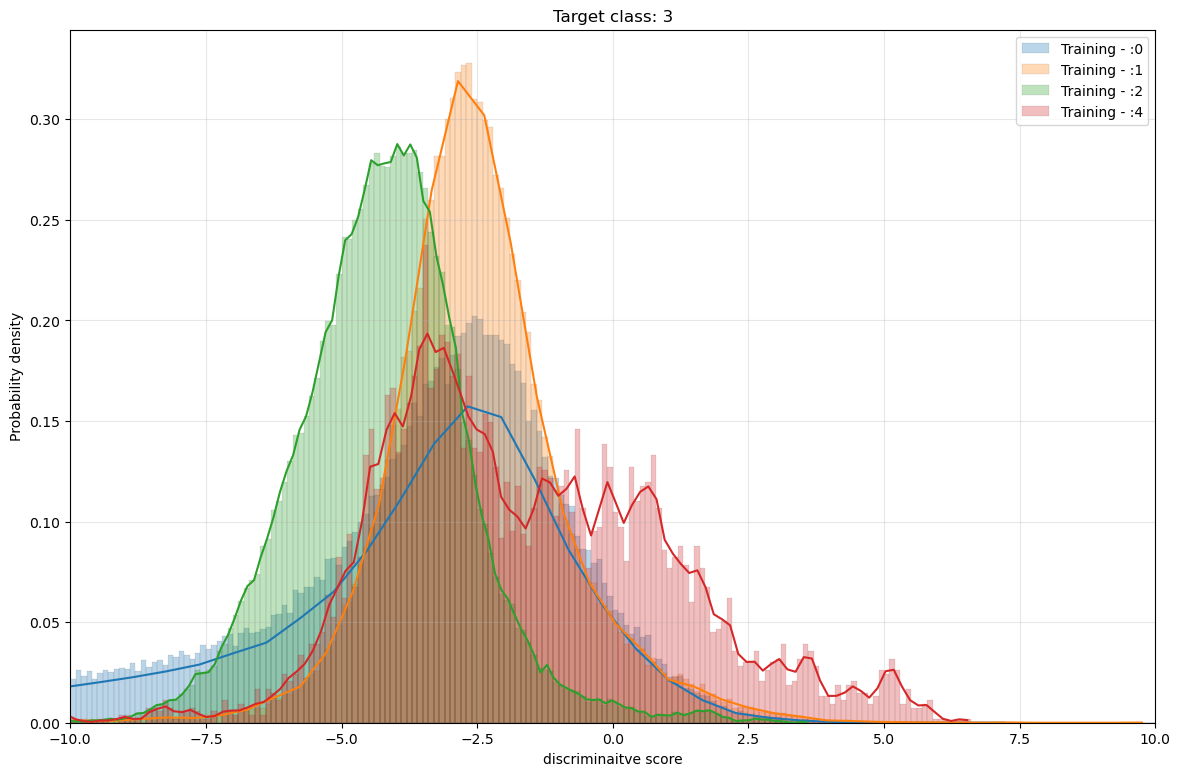

In [172]:

#Plot the training data score distributions

# torch.save({'total_preds':total_preds, 'total_features':total_features}, tensor_data_file_name)
tensor_data_file_name = out_root + "bcss.mini.training.torch"
# Load the training data
training_data = torch.load(tensor_data_file_name, weights_only=False)
training_preds = training_data['total_preds']
print(training_preds[0].shape)
max_class = 5
plt.figure(figsize=(14, 9))

# for target_class in range(max_class):
#     print("Target class: ", target_class)
target_class = 3

for other_classes in range(max_class):
    if target_class != other_classes:
        negative_data = training_preds[other_classes][target_class,:]
        a=sns.histplot(negative_data, bins=bins, stat="density", kde_kws={'bw_adjust': kde_bw}, kde=True, fill=True,  alpha=0.3, label="Training - :" + str(other_classes))    
        print("training negative max:", negative_data.max())
plt.xlabel('discriminaitve score')
plt.ylabel('Probability density')
plt.title("Target class: " + str(target_class))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.xlim(-10,10)

plt.show()


torch.Size([5, 100000])


C:\Users\kfattila\AppData\Local\Temp\ipykernel_10420\1962539580.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


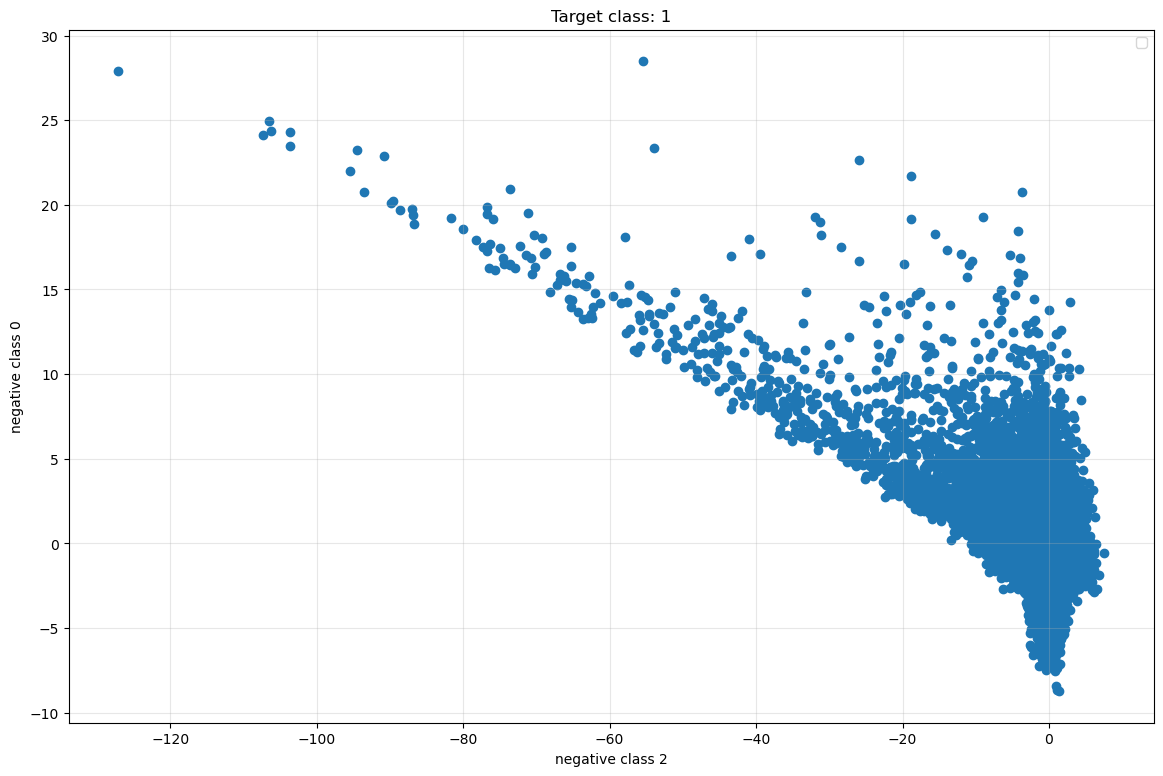

In [202]:
#Plot the training data score distributions

# torch.save({'total_preds':total_preds, 'total_features':total_features}, tensor_data_file_name)
tensor_data_file_name = out_root + "bcss.mini.training.torch"
# Load the training data
training_data = torch.load(tensor_data_file_name, weights_only=False)
training_preds = training_data['total_preds']
print(training_preds[0].shape)
max_class = 5
plt.figure(figsize=(14, 9))

# for target_class in range(max_class):
#     print("Target class: ", target_class)
target_class = 1
class_1 = 2
class_2 = 0
plt.scatter( training_preds[target_class][class_1,:], training_preds[target_class][class_2,:])
plt.xlabel('negative class '+ str(class_1))
plt.ylabel('negative class '+ str(class_2))
plt.title("Target class: " + str(target_class))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# plt.xlim(-10,10)

plt.show()


In [930]:
# a = torch.rand((3,4))
# print(a)
# mask = torch.tensor([2,0,1])
# col_indices = torch.arange(4).unsqueeze(0)  # 1xM
# print(col_indices)
# mask = col_indices != mask.unsqueeze(1)  # NxM - True for columns to keep
# print(mask.float())
        

In [932]:
# # Example
# matrix = torch.tensor([[1, 2, 3, 4],
#                        [4, 5, 6,5 ],
#                        [7, 8, 9, 11]])  # 3x3

# vector = torch.tensor([2, 3, 4])  # 3x1

# # Reshape vector to column (Nx1) and broadcast
# result = matrix * vector.unsqueeze(1)  # or vector[:, None]
# print(result)

In [33]:
class KOGen(torch.nn.Module):
    def __init__(self, input_dim, model_dim, output_dim, device=DEVICE):
        super(KOGen, self).__init__()
        self.activation = torch.nn.ReLU().to(device)
        # self.dropout = torch.nn.Dropout(p=0.05)
        
        # self.activation = torch.nn.Sigmoid().to('cuda')

        self.layer_1 = torch.nn.Linear(input_dim, model_dim, device=device)
        # self.layer_2 = torch.nn.Linear(model_dim, model_dim, device=device)
        # self.layer_3 = torch.nn.Linear(model_dim, model_dim, device=device)
        self.layer_out = torch.nn.Linear(model_dim, output_dim, device=device)

    def forward(self, x):
        hidden = self.activation(self.layer_1(x))
        # hidden = self.activation(self.layer_2(hidden))
        # hidden = self.activation(self.layer_3(hidden))
        out = self.layer_out(hidden)
        return out
        
class KO_loss(torch.nn.Module):
    def __init__(self, device=DEVICE):
        super().__init__()
        self.sigmoid = torch.nn.Sigmoid().to(device)
        self.eps = 1e-6
        self.tradeoff = 0.2
        self.device =  DEVICE

    def forward(self, predictions, targets, true_class):
        class_num = 5
        # print(true_class)
        # print(targets)
        # print(predictions)
        col_indices = torch.arange(class_num).unsqueeze(0).to(self.device)  # 1xM
        mask = col_indices != true_class.unsqueeze(1)  # NxM - True for columns to keep
        mask = mask.float()
        # print(mask)
        loss = (predictions-targets)**2
        masked_loss = loss * mask
        # print(masked_loss)
        # masked_target = targets * mask
        # print(masked_target)
        # target_mean = masked_target.mean(dim=0)
        # print(target_mean)
        # mask = (1.0-mask)*target_mean.unsqueeze(0)
        # print(mask)
        # masked_target = masked_target + mask
        # print(masked_target)

        loss_on_positive = -torch.log(1-self.sigmoid(predictions)+self.eps)
        # print(loss_on_positive)
        loss_on_positive = loss_on_positive*(1.0-mask)
        # print(loss_on_positive)

        final_loss = (1.0-self.tradeoff)*masked_loss.mean() + self.tradeoff*loss_on_positive.mean()
        
        return final_loss


In [43]:

generator = KOGen(64, 256, 5, device=DEVICE)
cost_fnc = KO_loss(device=DEVICE)

learning_rate = 0.0001
optimizer = torch.optim.Adam(generator.parameters(), lr=learning_rate)



number of samples for class:  0  is  400000
number of samples for class:  1  is  400000
number of samples for class:  2  is  368307
number of samples for class:  3  is  154293
number of samples for class:  4  is  0
torch.Size([1322600])
torch.Size([1322600, 64])
torch.Size([1322600, 5])
range(0, 1322600)
0.059984043


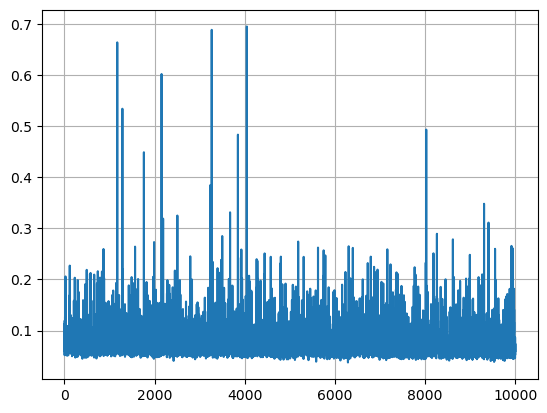

In [49]:
# Training

# torch.save({'total_preds':total_preds, 'total_features':total_features}, tensor_data_file_name)
# tensor_data_file_name = out_root + "bcss.mini.training.torch"
tensor_data_file_name = training_root + "bcss.local.training.torch"
# Load the training data
training_data = torch.load(tensor_data_file_name, weights_only=False)
training_preds = training_data['total_preds']
# print(training_preds[0].shape)

training_features = training_data['total_features']
# print(training_features)
max_class = 5
training_features_ = []
training_predictions_ = []
training_labels_ = []
for cur_class in range(max_class):
    data_num = training_features[cur_class].shape[1]
    print("number of samples for class: ", cur_class, " is ", data_num)
    class_labels = torch.zeros(data_num) + cur_class
    training_labels_.append(class_labels)
    training_features_.append(training_features[cur_class].transpose(0,1))
    training_predictions_.append(training_preds[cur_class].transpose(0,1))

labels = torch.cat(training_labels_).to(DEVICE)
features = torch.cat(training_features_).to(DEVICE)
predictions = torch.cat(training_predictions_).to(DEVICE)
print(labels.shape)
print(features.shape)
print(predictions.shape)


data_num = len(labels)
data_index = range(data_num)
print(data_index)

batch_size = 32
n_epoch = 10000
losses = []
for i in range(n_epoch):
    data_batch = random.sample(data_index, batch_size)
    # print(data_batch)
    preds = generator(features[data_batch,:])
    loss = cost_fnc(preds, predictions[data_batch,:], labels[data_batch])
    # print(preds)
    # print(loss.detach().cpu().numpy())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    # break
# test
# batch_size = 100000
# data_batch = random.sample(data_index, batch_size)
# preds = generator(features[data_batch,:])
# loss = cost_fnc(preds, predictions[data_batch,:], labels[data_batch])

print(loss.detach().cpu().numpy())
# print(preds)
# print(predictions[data_batch,:])
# print(labels[data_batch])
plt.plot(losses)
plt.grid()
plt.show()


torch.Size([1, 5, 2623, 2924])
torch.Size([7669652, 5])
torch.Size([7669652, 64])
torch.Size([7669652])
range(0, 7669652)
torch.Size([10000, 64])
number of positive data of target class:  0  is  2298


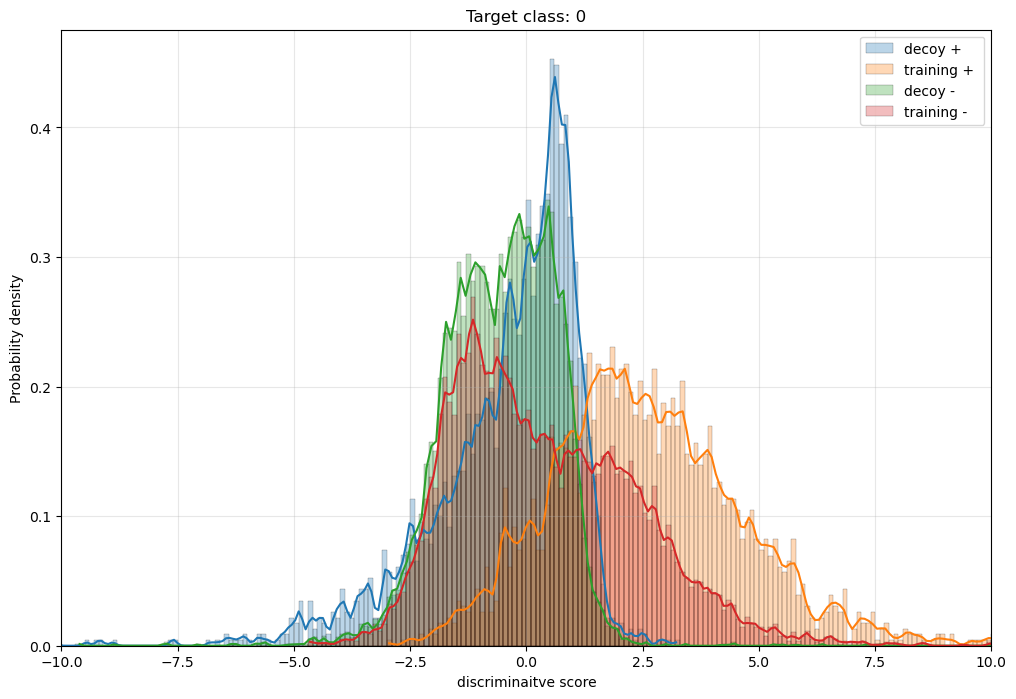

number of positive data of target class:  1  is  1571


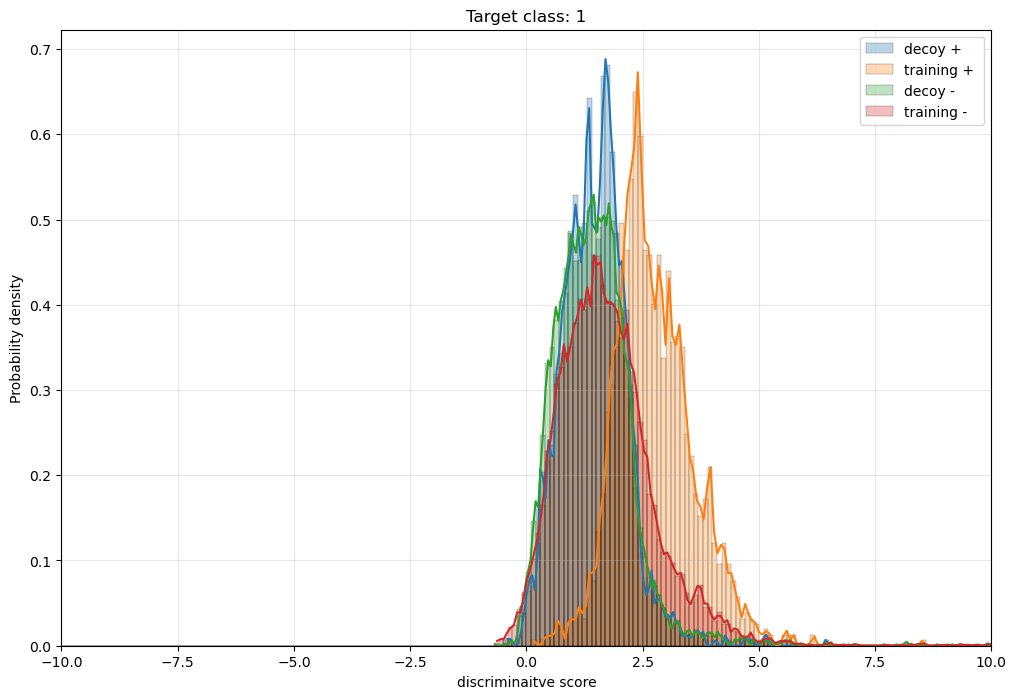

number of positive data of target class:  2  is  474


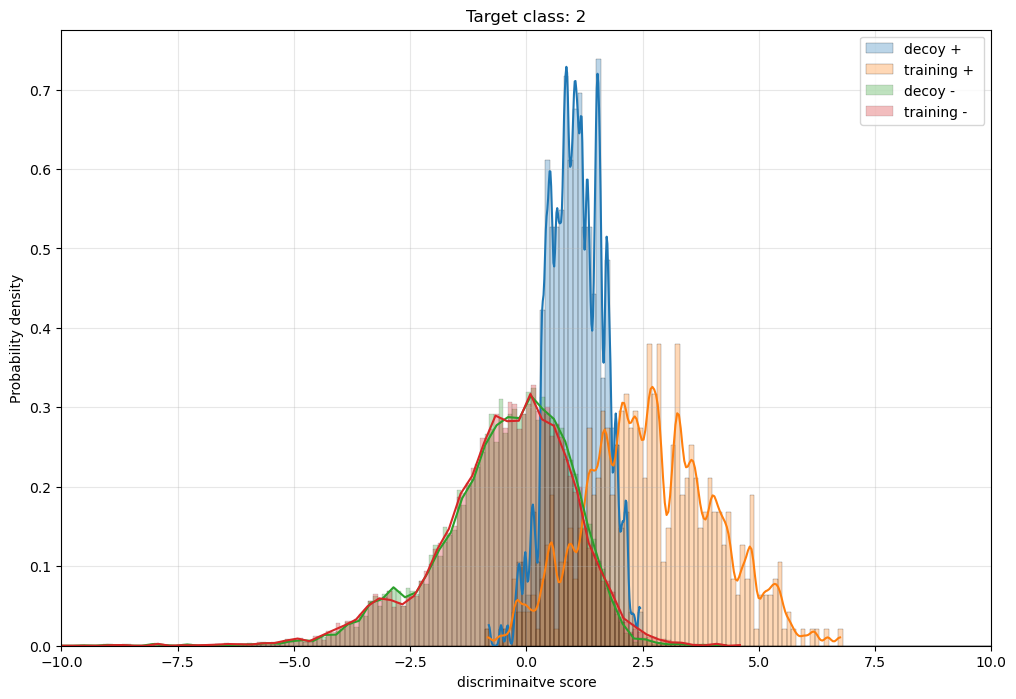

number of positive data of target class:  3  is  133


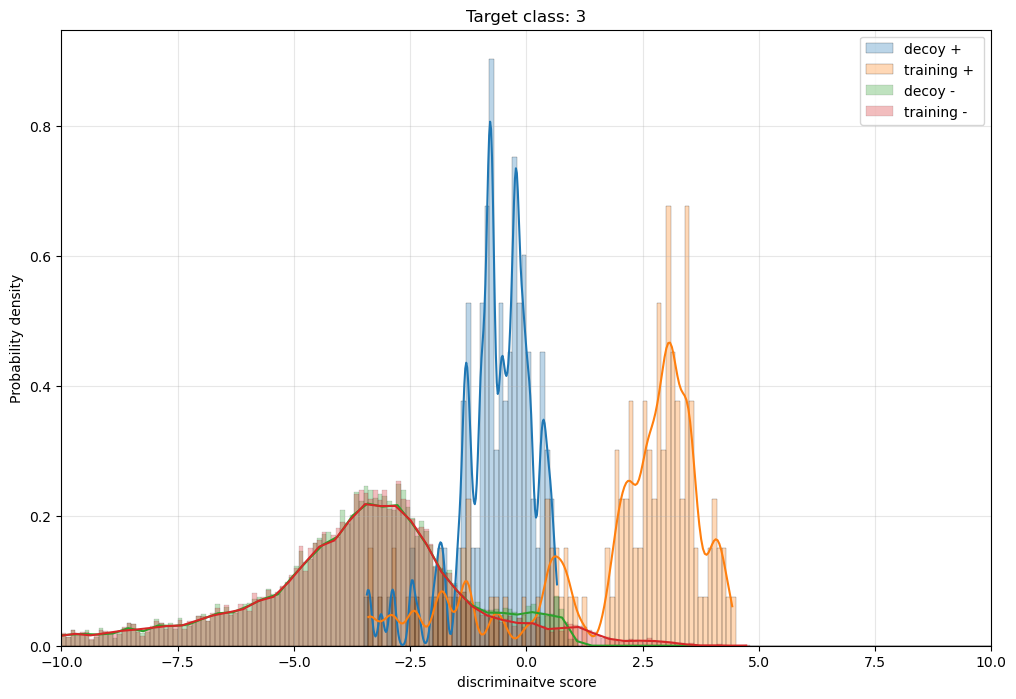

number of positive data of target class:  4  is  0


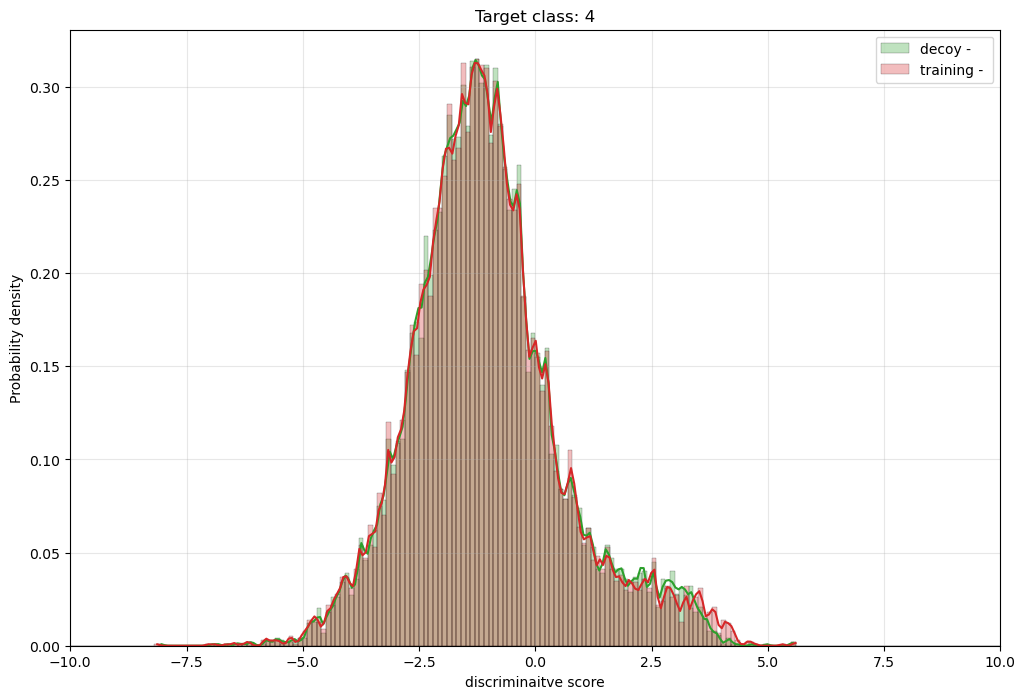

In [65]:


# test_file_name = "TCGA-E2-A1LS-DX1_xmin39247_ymin47756_MPP-0.2500.png.tensor"
# test_file_name = "TCGA-E2-A1LK-DX1_xmin75611_ymin27593_MPP-0.2500.png.tensor"
test_file_name = "TCGA-EW-A1PH-DX1_xmin3455_ymin52049_MPP-0.2500.png.tensor"
# test_file_name = "TCGA-GM-A2DF-DX1_xmin50637_ymin43774_MPP-0.2500.png.tensor"
# # Load the test data
test_data = torch.load(out_root+test_file_name, weights_only=False)

# test_file_name = "TCGA-HN-A2NL-DX1_xmin11931_ymin5764_MPP-0.2500.png.tensor"
# test_file_name = "TCGA-S3-AA10-DX1_xmin43039_ymin23986_MPP-0.2500.png.tensor"
# # Load the test data
# test_data = torch.load(test_root+test_file_name, weights_only=False)



predictions = test_data['predictions']
features = test_data['features']
labels = torch.tensor(test_data['mask'])
print(predictions.shape)
predictions = torch.flatten(predictions, start_dim=2).squeeze(0).transpose(0,1).to(DEVICE)
features = torch.flatten(features, start_dim=2).squeeze(0).transpose(0,1).to(DEVICE)
labels = torch.flatten(labels, start_dim=0).to(DEVICE)
# labels[labels>4]=4
# print(torch.max(labels))
print(predictions.shape)
print(features.shape)
print(labels.shape)


data_num = len(labels)
data_index = range(data_num)
print(data_index)


# # test
batch_size = 10000
data_batch = random.sample(data_index, batch_size)
print(features[data_batch,:].shape)
preds = generator(features[data_batch,:])
# loss = cost_fnc(preds, predictions[data_batch,:], labels[data_batch])

# print(loss.detach().cpu().numpy())
# print(preds)
# print(predictions[data_batch,:])
# print(labels[data_batch])

max_class =5 
decoys = preds.detach().cpu().numpy()
true_predictions =  predictions[data_batch,:].detach().cpu().numpy()

# df_tdc = control_fdr_multiclass(true_predictions, labels[data_batch].cpu().numpy(), decoys)
# qvals = df_tdc['q_values_ground_truth']


# print(qvals)
bins=np.arange(-11,31,0.1)
kde_bw = 0.2
for target_class in range(max_class):
    positive_index = (labels[data_batch] == target_class).cpu().numpy()
    print("number of positive data of target class: ", target_class, " is ", sum(positive_index))
    # print(preds)
    plt.figure(figsize=(12, 8))    
    a=sns.histplot(decoys[positive_index,target_class], bins=bins, stat="density", kde_kws={'bw_adjust': kde_bw}, kde=True, fill=True,  alpha=0.3, label="decoy + " )    
    a=sns.histplot(true_predictions[positive_index,target_class], bins=bins, stat="density", kde_kws={'bw_adjust': kde_bw}, kde=True, fill=True,  alpha=0.3, label="training + ")    
    negative_index = (labels[data_batch] != target_class).cpu().numpy()
    a=sns.histplot(decoys[negative_index,target_class], bins=bins, stat="density", kde_kws={'bw_adjust': kde_bw}, kde=True, fill=True,  alpha=0.3, label="decoy - ")    
    a=sns.histplot(true_predictions[negative_index,target_class], bins=bins, stat="density", kde_kws={'bw_adjust': kde_bw}, kde=True, fill=True,  alpha=0.3, label="training - ")    

    plt.xlabel('discriminaitve score')
    plt.ylabel('Probability density')
    plt.title("Target class: " + str(target_class))
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.xlim(-10,10)
    plt.show()
    
    # break

    

C:\Users\kfattila\AppData\Local\Temp\ipykernel_27492\178277442.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


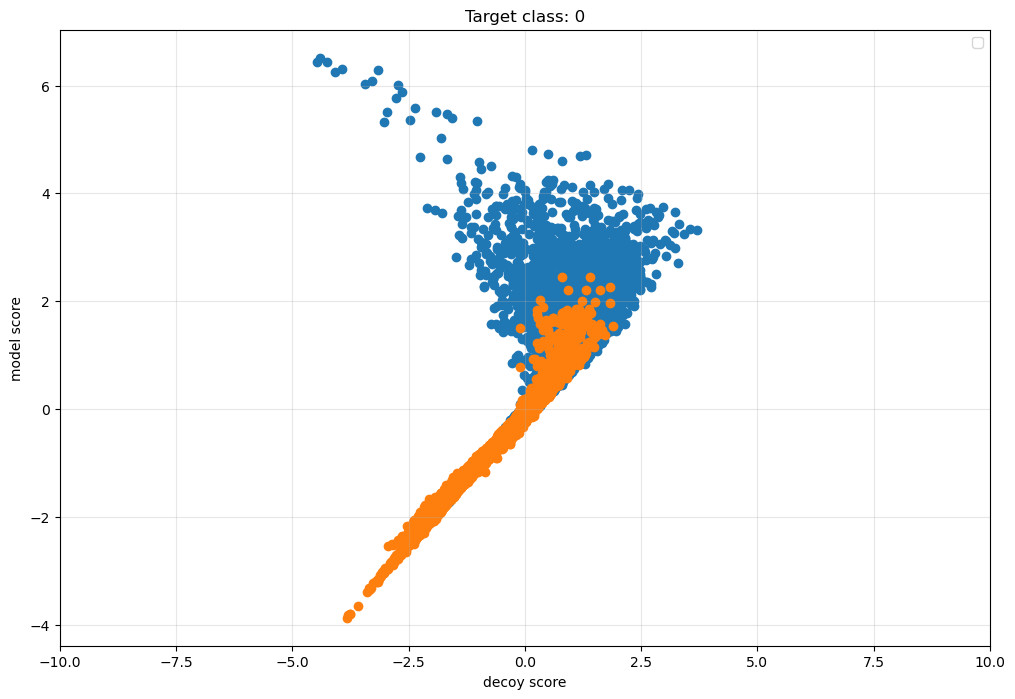

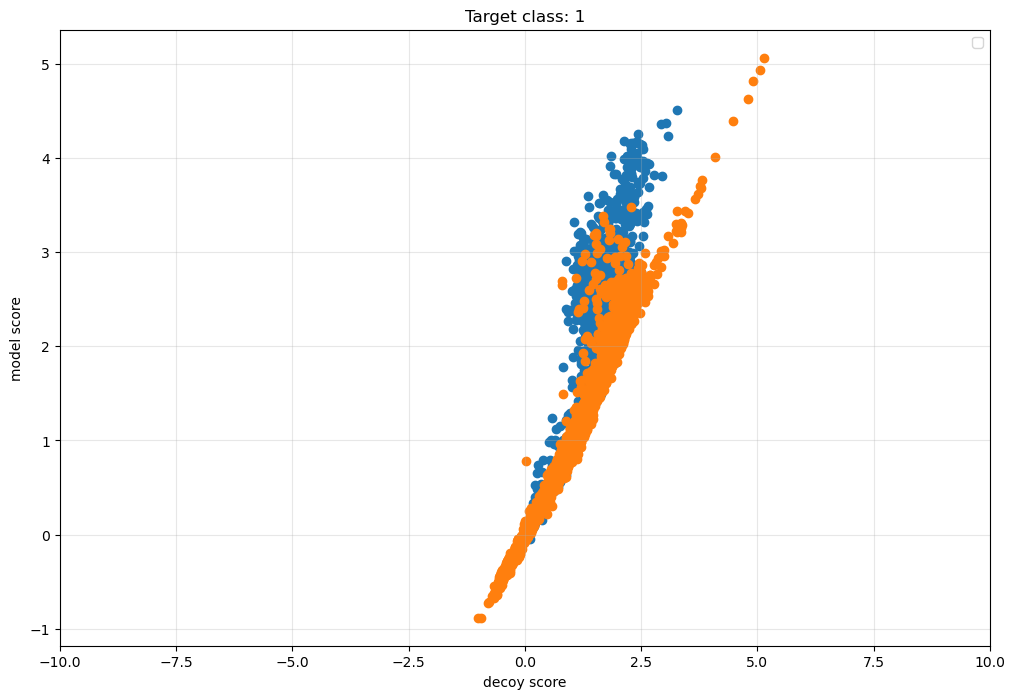

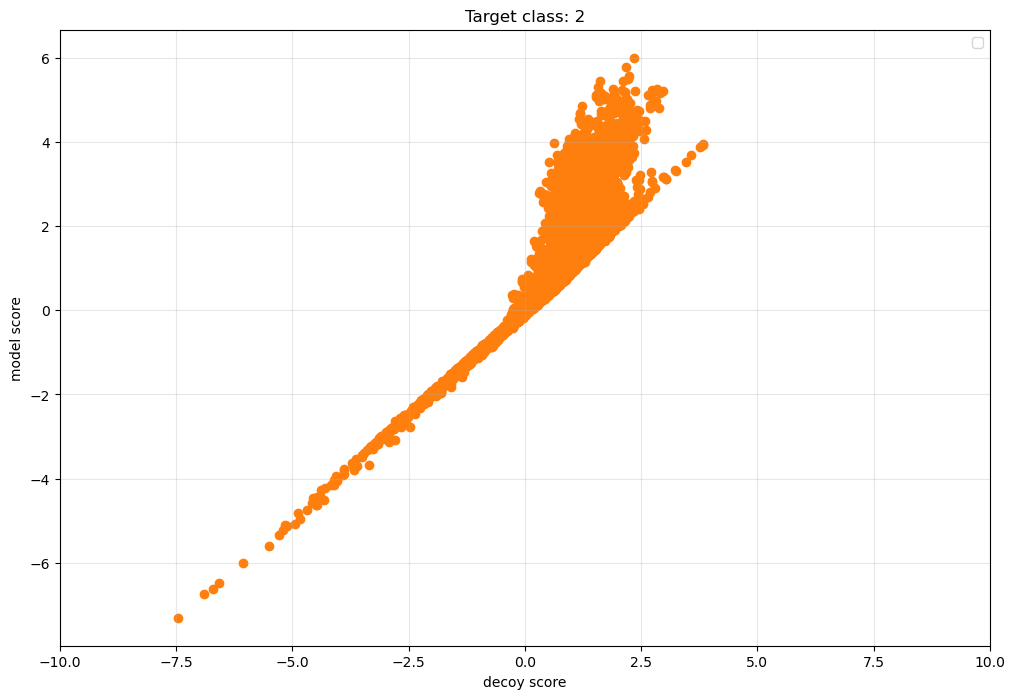

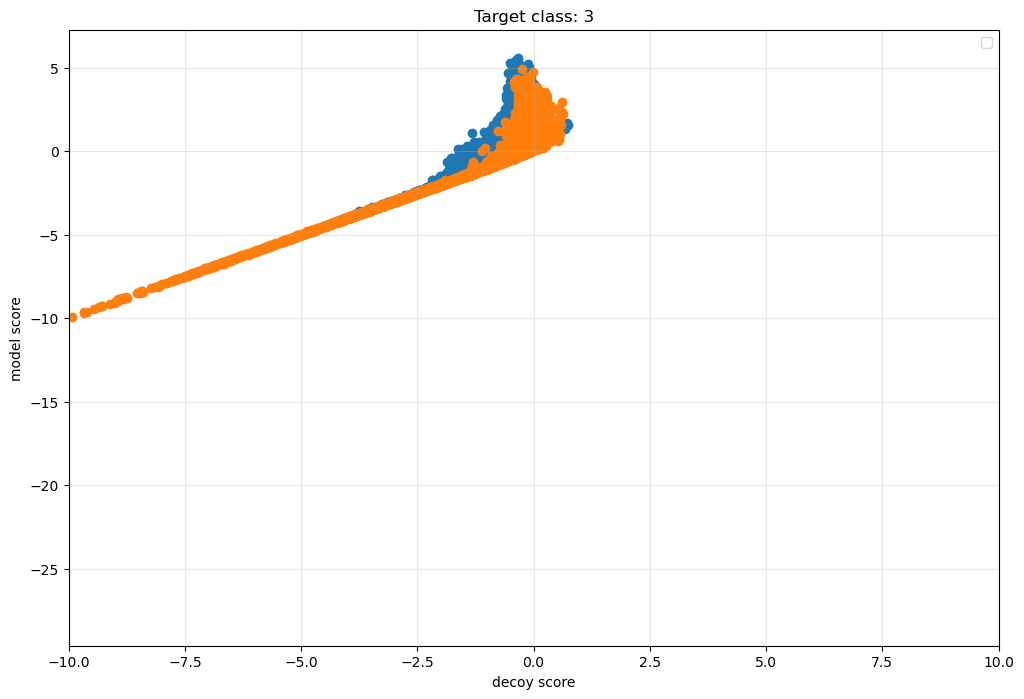

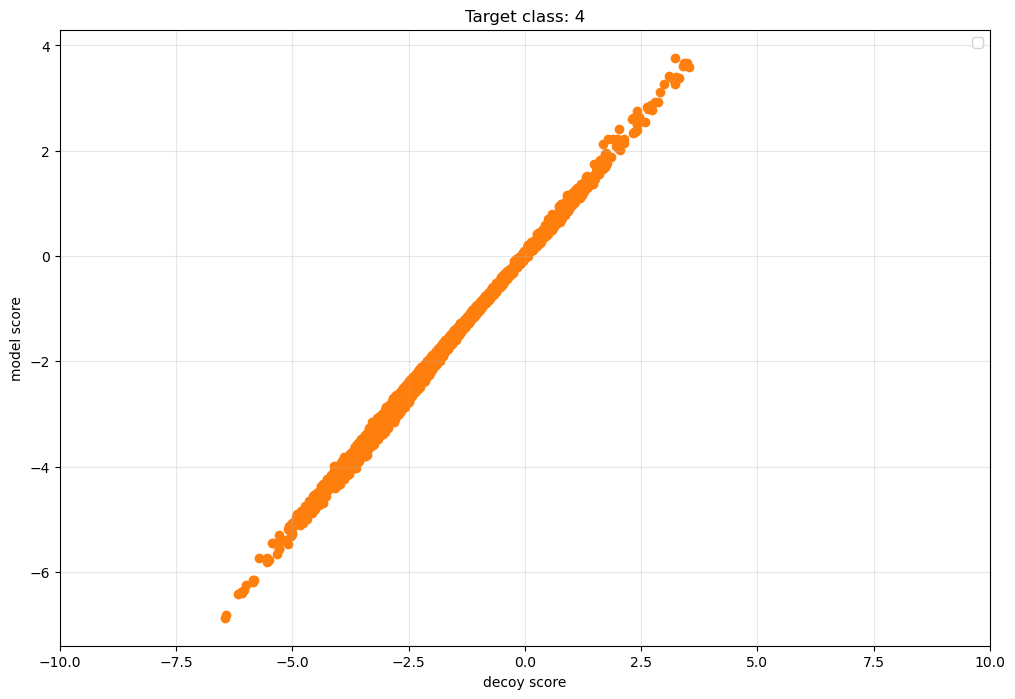

In [23]:
# # test
batch_size = 10000
data_batch = random.sample(data_index, batch_size)
preds = generator(features[data_batch,:])
loss = cost_fnc(preds, predictions[data_batch,:], labels[data_batch])

max_class =5 
preds = preds.detach().cpu().numpy()
true_predictions =  predictions[data_batch,:].detach().cpu().numpy()
for target_class in range(max_class):
    positive_index = (labels[data_batch] == target_class).cpu().numpy()
    # print(positive_index)
    # print(preds)
    plt.figure(figsize=(12, 8))    
    plt.scatter(preds[positive_index,target_class], true_predictions[positive_index,target_class])
    negative_index = (labels[data_batch] != target_class).cpu().numpy()
    plt.scatter(preds[negative_index,target_class], true_predictions[negative_index,target_class])
    # a=sns.histplot(preds[negative_index,target_class], bins=bins, stat="density", kde_kws={'bw_adjust': kde_bw}, kde=True, fill=True,  alpha=0.3, label="decoy - ")    
    # a=sns.histplot(true_predictions[negative_index,target_class], bins=bins, stat="density", kde_kws={'bw_adjust': kde_bw}, kde=True, fill=True,  alpha=0.3, label="training - ")    

    plt.xlabel('decoy score')
    plt.ylabel('model score')
    plt.title("Target class: " + str(target_class))
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.xlim(-10,10)
    plt.show()
    

In [29]:
# # test
batch_size = 10000
data_batch = random.sample(data_index, batch_size)
decoys = generator(features[data_batch,:])
loss = cost_fnc(decoys, predictions[data_batch,:], labels[data_batch])

# print(loss.detach().cpu().numpy())
# print(preds)
# print(predictions[data_batch,:])
# print(labels[data_batch])
softmax = torch.nn.Softmax(dim=1)
max_class =5 
decoys = decoys.detach().cpu().numpy()
true_predictions =  predictions[data_batch,:].detach().cpu().numpy()
# true_predictions =  softmax(predictions[data_batch,:]).detach().cpu().numpy()

df_tdc = control_fdr_multiclass(true_predictions, labels[data_batch].cpu().numpy(), decoys)
# qvals = df_tdc['q_values_ground_truth']
qvals = np.sort(df_tdc['q_values_ground_truth'])
plt.plot(qvals, np.arange(len(qvals)))
# qvals = df_tdc['q_values_tdc']
# qvals = np.sort(df_tdc['q_values_tdc'])
# print(qvals)
# plt.plot(qvals, np.arange(len(qvals)))
plt.show()

NameError: name 'control_fdr_multiclass' is not defined